## Задание 2

In [8]:
from checking_account import CheckingAccount
from savings_account import SavingsAccount
import time
import datetime

#### CheckingAccount проверка работы

In [9]:
checking = CheckingAccount("Иван Иванов", 1000)
time.sleep(1)
checking.deposit(500)
time.sleep(1)
checking.withdraw(200)
time.sleep(1)
checking.withdraw(800)

print(f"Баланс расчетного счета: {checking.get_balance()}")

Баланс расчетного счета: 500


#### SavingsAccount проверка работы

In [10]:
savings = SavingsAccount("Мария Петрова", 2000)
time.sleep(1)
savings.deposit(1000)
time.sleep(1)

# Попытка снять больше 50% от баланса
try:
    savings.withdraw(2000)
    time.sleep(1)
except ValueError as e:
    print(f"Ошибка снятия: {e}")

savings.withdraw(500)
time.sleep(1)
savings.deposit(1500)
time.sleep(1)

# Начисление процентов
interest = savings.apply_interest(0.05)
print(f"Начислены проценты: {interest:.2f}")
print(f"Баланс сберегательного счета после начисления процентов: {savings.get_balance():.2f}")

Ошибка снятия: Нельзя снять более 50% от текущего баланса. Максимально доступно: 1500.00
Начислены проценты: 200.00
Баланс сберегательного счета после начисления процентов: 4200.00


#### Крупные операции

In [11]:
large_ops = savings.get_large_operations(n=3, min_amount=500)
print("Крупные операции:")
for op in large_ops:
    print(f"  {op['timestamp'].strftime('%Y-%m-%d %H:%M')} - {op['type']}: {op['amount']:.2f} (баланс: {op['balance_after']:.2f})")

Крупные операции:
  2025-11-08 11:59 - deposit: 1500.00 (баланс: 4000.00)
  2025-11-08 11:59 - withdraw: 2000.00 (баланс: 3000.00)
  2025-11-08 11:59 - withdraw: 500.00 (баланс: 2500.00)


#### Анализ операций по дате

In [12]:
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=7)
analysis = savings.analyze_operations_by_date(start_date, end_date)
for key, value in analysis.items():
    print(f"  {key}: {value}")

  total_operations: 6
  total_deposits: 2
  total_withdrawals: 2
  successful_operations: 5
  failed_operations: 1
  total_deposit_amount: 2500
  total_withdrawal_amount: 500
  period_start: 2025-11-01 11:59:16.789223
  period_end: 2025-11-08 11:59:16.789223


#### Проверка валидации имени

In [13]:
try:
    invalid_account = CheckingAccount("иван иванов", 100)  # Маленькие буквы
except ValueError as e:
    print(f"Ошибка валидации: {e}")

try:
    invalid_account = SavingsAccount("Иван", 100)  # Только одно слово
except ValueError as e:
    print(f"Ошибка валидации: {e}")

Ошибка валидации: Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв
Ошибка валидации: Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв


#### Графики

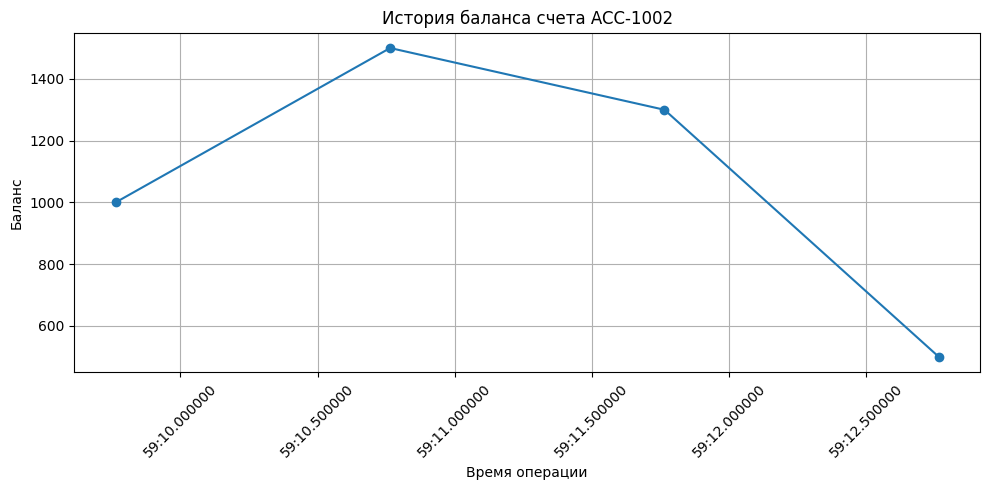

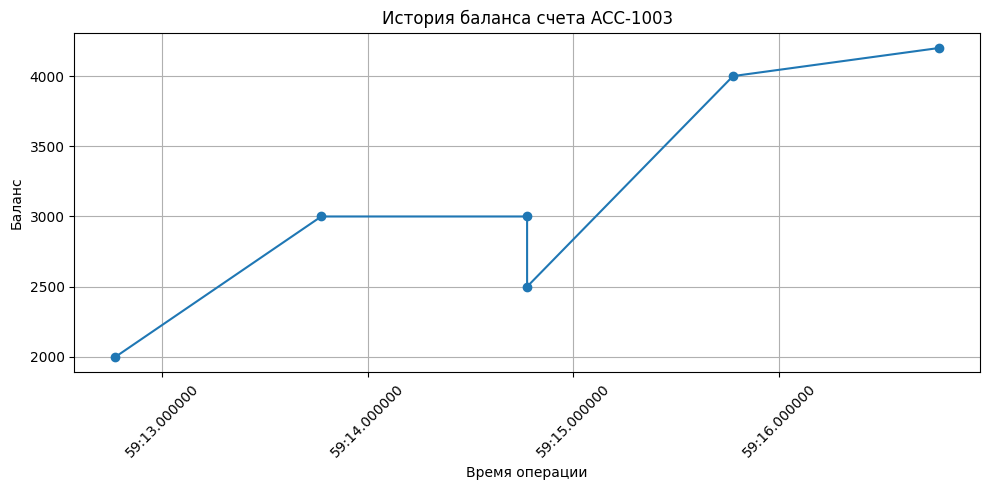

In [14]:
checking.plot_history()
savings.plot_history()